In [1]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt 
import pyvista as pv
import scipy.integrate as integration

In [2]:
alpha=1j
N=30
psi=coherent(N=N,alpha=alpha) #Truncation, mean photons should be very very less than the Total number.
a=destroy(N)
aDagger=create(N)

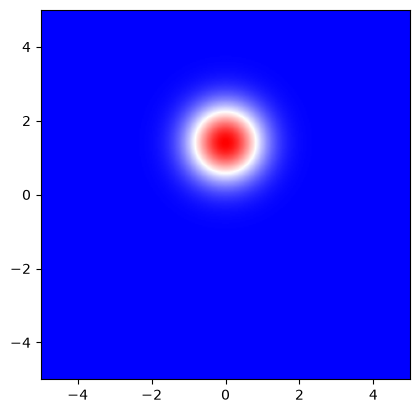

In [3]:
x=np.linspace(-5,5,300)
p=np.linspace(-5,5,300)
w=wigner(psi,x,p)
plt.imshow(w,extent=[-5, 5, -5, 5], origin='lower', cmap='bwr')
plt.show()


In [4]:
X,Y=np.meshgrid(x,p)
surface=pv.StructuredGrid(X, Y, w)

ptr=pv.Plotter()
surface["Zv"]=w.ravel(order = "F")
mesh= ptr.add_mesh(surface,scalars="Zv",cmap="hot")
ptr.show_grid()

ptr.show()

Widget(value='<iframe src="http://localhost:49427/index.html?ui=P_0x1c2f5a2aa50_0&reconnect=auto" class="pyvis…

In [5]:
intim=integration.simpson(w,x,axis=0)
intval=integration.simpson(intim,p)
print(f"Integral of Weigner Function- {intval}")


Integral of Weigner Function- 0.9999998021695174


$$\langle f(x,p)\rangle
=
\iint f(x,p)W(x,p)\,dx\,dp$$
$$
\alpha = i$$
$$\mathrm{Re}(\alpha)=0$$
$$\mathrm{Im}(\alpha)=1$$
$$\langle x\rangle = \sqrt2\,\mathrm{Re}(\alpha)=0$$
$$\langle p\rangle = \sqrt2\,\mathrm{Im}(\alpha)=\sqrt2$$

In [14]:
dx=x[1]-x[0]
dp=p[1]-p[0]
xExpectation=np.sum(w*X)*dx*dp #type:ignore
print(f"X expectation value - {xExpectation}")
pExpectation=np.sum(w*Y)*dx*dp #type:ignore
print(f"P expectation value - { pExpectation}")

X expectation value - 1.3701580908802573e-17
P expectation value - 1.4142126657726226
